In [1]:
%cd ..

/Users/juansegundohevia/Documents/neni/skill_scraping


In [2]:
import pandas as pd 
import numpy as np 
import json 
import matplotlib.pyplot as plt

In [3]:
import os


RESULTS_PATHS = [
    "data/jobs/job_data_20250501_2248_index0",
    "data/jobs/job_data_20250501_2321_index128",
]

def load_results(path):
    
    _path_results = []

    for res in os.listdir(path):
        if not res.endswith(".json"):
            continue
        
        try:
            with open(os.path.join(path, res), "r") as f:
                row_data = json.load(f)

            # add ID to row_data
            row_data["id"] = res.split(".")[0]
            # add path to row_data
            row_data["path"] = path

            _path_results.append(row_data)
        except Exception as e:
            print(f"Error loading {res}: {e}")
            continue

    return _path_results

data = []

for path in RESULTS_PATHS:
    path_results = load_results(path)
    data.extend(path_results)

df = pd.DataFrame(data)
df.info()
            

Error loading 01JT7KGHBVTE4V4216QZ8H67HC.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7KRE7F3GKM3Q5XJ2286DYR.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7KQAZCN2GG8RDS8EAJ4MHH.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7QAGQDXJXB7F4G2DAHQZ02.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7RK2F3MZ6Y76TGQ67VQKXH.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7SAAHB8TJATTWWDJCFHYXT.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7SFN10MNTA3ECT9NWXR4ER.json: Expecting value: line 1 column 1 (char 0)
Error loading 01JT7NT7DSC697338X35FHW0J1.json: Expecting value: line 1 column 1 (char 0)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        674 non-null    object
 1   company      674 non-null    object
 2   location     6

In [4]:
# explode the skills column
skills_data = df.explode("skills", ignore_index=True).copy()

In [5]:
# preprocess the "skills" column, which is a dictionary
skills_data["skill_name"] = skills_data.skills.apply(lambda x: list(x.values())[0] if isinstance(x, dict) else x)
skills_data["skill_motive"] = skills_data.skills.apply(lambda x: list(x.values())[1] if isinstance(x, dict) else x)

# drop the original "skills" column
skills_data.drop(columns=["skills",
                          "md_text",
                          ], inplace=True)

skills_data.info()
# check the first few rows
skills_data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3341 entries, 0 to 3340
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         3341 non-null   object
 1   company       3341 non-null   object
 2   location      3341 non-null   object
 3   description   3341 non-null   object
 4   mode          3341 non-null   object
 5   seniority     3341 non-null   object
 6   url           3341 non-null   object
 7   id            3341 non-null   object
 8   path          3341 non-null   object
 9   skill_name    3341 non-null   object
 10  skill_motive  3341 non-null   object
dtypes: object(11)
memory usage: 287.2+ KB


,title,company,location,description,mode,seniority,url,id,path,skill_name,skill_motive
0,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Experiencia comercial,Es esencial para identificar y satisfacer las ...
1,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Ventas del rubro automotriz,Valiosa para comprender el mercado y ofrecer u...
2,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Venta telefónica,Importante para la captación de clientes y gen...
3,Asesores comerciales (venta de salón) para la ...,Grupo Taraborelli,"Capital Federal, Buenos Aires, Argentina",Grupo Taraborelli está formado por 10 empresas...,presencial,junior,https://bumeran.com.ar/empleos/vendedor-de-sal...,01JT7JGHJFSTZJPNGBJXS666MR,data/jobs/job_data_20250501_2248_index0,Call center,Habilidad necesaria para manejar consultas y c...
4,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Excel intermedio,Es necesario para gestionar datos y análisis e...
5,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Conocimiento de canales de venta digital,Requerido para brindar soporte y manejo adecua...
6,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Gestión de contingencias operativas,Importante para garantizar términos de planifi...
7,Analista E-commerce,Arch Latam,"Capital Federal, Buenos Aires, Argentina",Desde Arch Latam nos encontramos en búsqueda d...,presencial,semi-senior,https://bumeran.com.ar/empleos/analista-e-comm...,01JT7KD50ZPFPKEWCSAP4JJ9GW,data/jobs/job_data_20250501_2248_index0,Proactividad y flexibilidad,Valioso para adaptarse a un entorno dinámico y...
8,Recepcionista,Importante cadena de Farmacias,"San Martin, Buenos Aires, Argentina","Buscamos una persona organizada, proactiva, co...",presencial,junior,https://bumeran.com.ar/empleos/recepcionista-g...,01JT7JHFC55SC1ZAN0VCTFZX85,data/jobs/job_data_20250501_2248_index0,Atención al cliente,Es esencial para recibir y guiar a los cliente...
9,Recepcionista,Importante cadena de Farmacias,"San Martin, Buenos Aires, Argentina","Buscamos una persona organizada, proactiva, co...",presencial,junior,https://bumeran.com.ar/empleos/recepcionista-g...,01JT7JHFC55SC1ZAN0VCTFZX85,data/jobs/job_data_20250501_2248_index0,Comunicación verbal,Se requiere para mantener un trato amable y co...


# Calcular Embeddings

In [6]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("nomic-ai/modernbert-embed-base", truncate_dim=256)

In [7]:
merged_skill_data = skills_data.skill_name.str.cat(skills_data.skill_motive, sep=" - ")
merged_skill_data[0]

'Experiencia comercial - Es esencial para identificar y satisfacer las necesidades de los clientes en el sector automotriz.'

# Probar embeddings

In [8]:
names = skills_data.skill_name.copy().tolist()
names[:3]

['Experiencia comercial', 'Ventas del rubro automotriz', 'Venta telefónica']

In [9]:
name_embs = model.encode(names, show_progress_bar=True, device="mps")

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

In [10]:
type(name_embs), name_embs.shape

(numpy.ndarray, (3341, 256))

## Calcular clusters vía K-Means

In [11]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [13]:
MAX_CENTERS = 50
NUM_CENTERS = np.arange(4, MAX_CENTERS, step=2)

def compute_kmeans(X, n_clusters):
    _x = X.copy() # make a copy of the data to avoid modifying the original

    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        init="k-means++",
        batch_size=64)
    
    kmeans.fit(_x)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    inertia = kmeans.inertia_
    silhouette = silhouette_score(_x, labels)
    return labels, centers, inertia, silhouette

res = compute_kmeans(name_embs, 5)

In [14]:
from tqdm import tqdm

PCA_COMPONENTS = 20
_x = name_embs.copy() # make a copy of the data to avoid modifying the original

# compute PCA
if PCA_COMPONENTS is not None:
    pca = PCA(n_components=PCA_COMPONENTS)
    _x = pca.fit_transform(_x)
    print(f"Explained variance: {np.sum(pca.explained_variance_ratio_)}")


# compute kmeans for all centers
kmeans_results = []
for n_centers in tqdm(NUM_CENTERS):

    labels, centers, inertia, silhouette = compute_kmeans(_x, n_centers)
    kmeans_results.append({
        "n_centers": n_centers,
        "labels": labels,
        "centers": centers,
        "inertia": inertia,
        "silhouette": silhouette
    })
# convert to dataframe
kmeans_df = pd.DataFrame(kmeans_results)

Explained variance: 0.5105770230293274


100%|██████████| 23/23 [00:01<00:00, 13.12it/s]


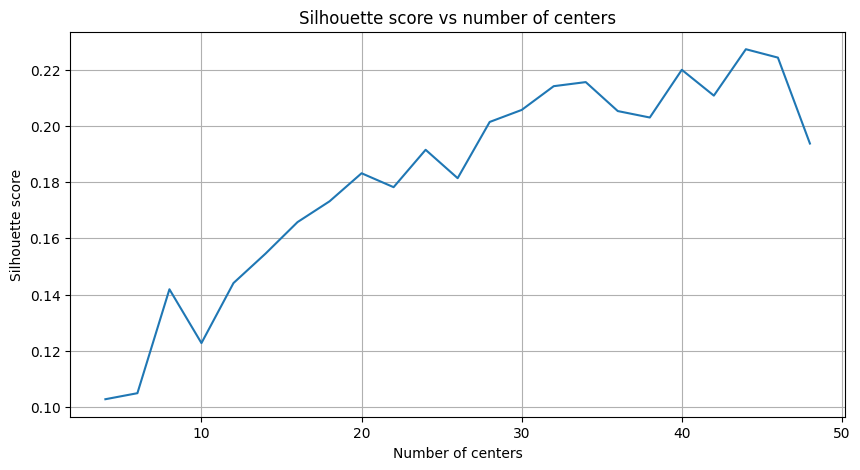

In [15]:
# plot silhouette score
plt.figure(figsize=(10, 5))
plt.plot(kmeans_df.n_centers, kmeans_df.silhouette)
plt.xlabel("Number of centers")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs number of centers")
plt.grid()

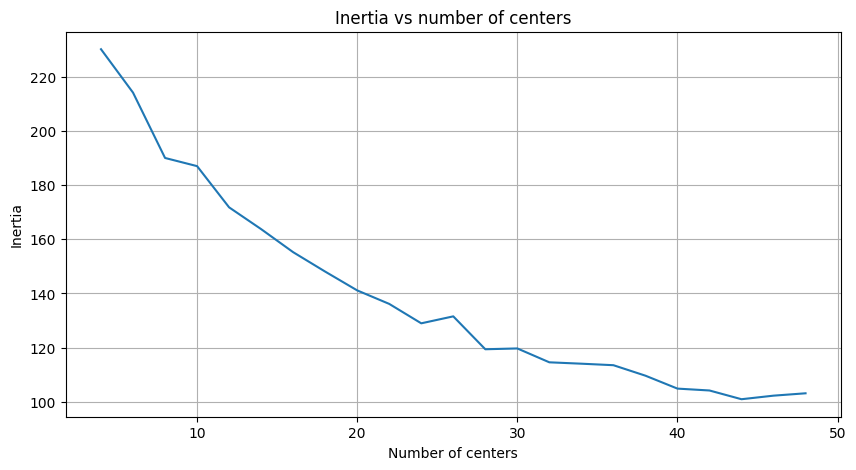

In [16]:
kmeans_df.sort_values("n_centers", inplace=True)

# plot inertia
plt.figure(figsize=(10, 5))
plt.plot(kmeans_df.n_centers, kmeans_df.inertia)
plt.xlabel("Number of centers")
plt.ylabel("Inertia")
plt.title("Inertia vs number of centers")
plt.grid()
plt.show()

In [17]:
kmeans_df.sort_values("silhouette", ascending=False, inplace=True)
kmeans_df.head(20)

,n_centers,labels,centers,inertia,silhouette
20,44,"[20, 8, 8, 25, 24, 11, 22, 14, 19, 17, 12, 25,...","[[0.09901083, -0.08297914, 0.049582373, -0.065...",100.898643,0.227252
21,46,"[35, 12, 12, 20, 23, 19, 36, 27, 4, 25, 16, 22...","[[-0.110416725, 0.11536914, -0.052066192, 0.00...",102.215637,0.224270
18,40,"[33, 3, 37, 5, 3, 26, 23, 9, 6, 12, 11, 0, 6, ...","[[0.11094121, -0.08078274, -0.11650993, -0.023...",104.822128,0.219930
15,34,"[11, 8, 30, 5, 6, 8, 18, 22, 7, 24, 9, 17, 7, ...","[[-0.29348078, -0.11818486, -0.10152467, -0.05...",114.029846,0.215563
14,32,"[19, 17, 17, 13, 24, 25, 2, 12, 9, 30, 28, 13,...","[[0.12405405, -0.02372514, 0.028248342, -0.015...",114.539360,0.214113
19,42,"[21, 32, 16, 34, 40, 28, 30, 3, 6, 4, 37, 34, ...","[[-0.0022656957, 0.13031222, -0.09380243, 0.06...",104.127998,0.210757
13,30,"[29, 20, 20, 25, 21, 11, 19, 8, 17, 5, 25, 0, ...","[[0.09897479, -0.0647535, -0.10002777, -0.0031...",119.664513,0.205670
16,36,"[2, 27, 28, 13, 10, 27, 11, 1, 34, 0, 33, 13, ...","[[-0.20693022, -0.04524497, -0.06332358, 0.026...",113.473648,0.205265
17,38,"[25, 17, 17, 32, 13, 30, 28, 10, 16, 33, 18, 3...","[[0.14454883, -0.048624504, -0.047519095, -0.0...",109.598953,0.202972
12,28,"[1, 3, 3, 0, 12, 13, 22, 15, 8, 9, 0, 23, 8, 2...","[[-0.174406, -0.11551576, 0.011833889, -0.1703...",119.366638,0.201395


In [18]:
TARGET_CENTER = 16
# fit the kmeans model with the best silhouette score
kmeans = MiniBatchKMeans(
    n_clusters=TARGET_CENTER,
    init="k-means++",
    batch_size=64)
kmeans.fit(_x)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# assign the labels to the original data
clustered_data = skills_data.copy()
clustered_data["cluster"] = labels
clustered_data["cluster"] = clustered_data["cluster"].astype(str)

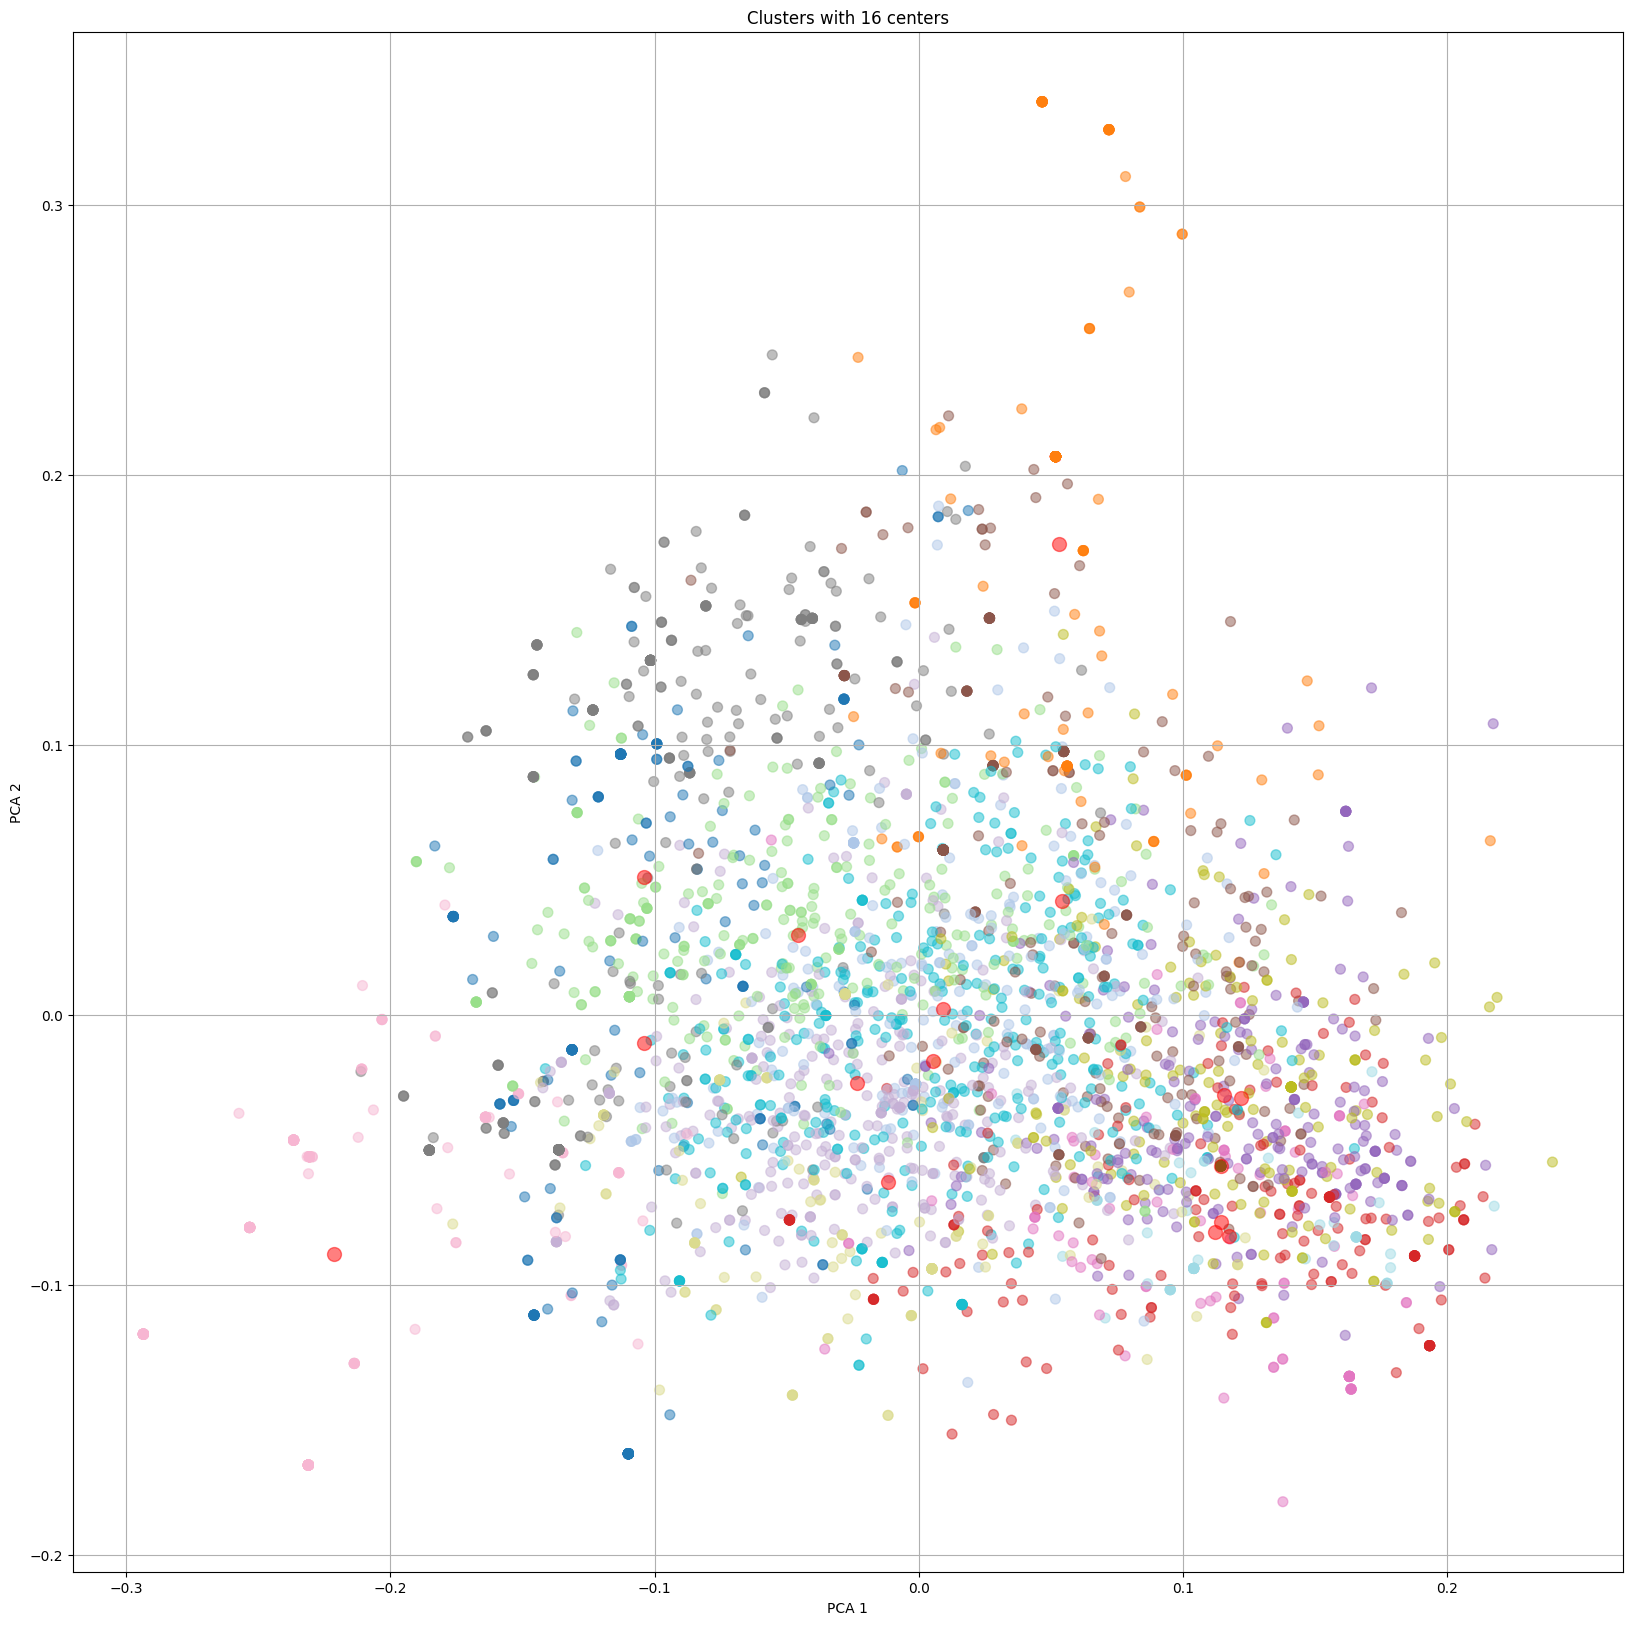

In [19]:
# visualize the clusters
# transform to 2D using PCA
_plot_pca = PCA(n_components=2).fit(_x)
_plot_x = _plot_pca.transform(_x)
_centers = _plot_pca.transform(centers)

plt.figure(figsize=(20,20))
plt.scatter(_plot_x[:, 0], _plot_x[:, 1], c=labels, s=50, cmap="tab20", alpha=0.5)
plt.scatter(_centers[:, 0], _centers[:, 1], c="red", s=100, alpha=0.5)
plt.title(f"Clusters with {TARGET_CENTER} centers")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid()

In [20]:
# get sample results from each cluster
# idx_cls = np.random.choice(clustered_data.cluster.unique())
idx_cls = "2"

sample_results = clustered_data[clustered_data.cluster == idx_cls].sample(10)

print(f"Cluster: {idx_cls}")
# print skill name for each sample result
for i, row in sample_results.iterrows():
    print(f"Skill name: {row.skill_name} - {row.skill_motive}")

Cluster: 2
Skill name: Manejo de equipos - Requerido para dirigir y optimizar el trabajo del equipo de producción.
Skill name: Mantenimiento de equipos - Debido a la naturaleza del trabajo, se necesita experiencia para realizar reparaciones efectivas.
Skill name: Liderazgo de equipos - Deseable para garantizar un correcto funcionamiento y organización del área.
Skill name: Trabajo en equipo - Es esencial para colaborar con otros operarios y seguir los procesos de producción.
Skill name: Trabajo en equipo - Una competencia esencial para coordinar con distintos departamentos y asegurar efectividad.
Skill name: Trabajo en equipo - Es esencial para coordinar con otros operarios y la cajera.
Skill name: Supervisión de equipos - Es esencial para asegurar el control diario del presentismo y la efectividad del trabajo realizado.
Skill name: Capacidad para trabajar en equipo e independientemente - El trabajo requiere colaboración con el equipo de ventas y también la habilidad de realizar tareas

Algunos clusters que vi:

7 - comunicación interpersonal

11 - computación y análisis (Excel, PC)

2 - soft skills / proactividad

In [21]:
# consolidate all functions
def test_centers(X, n_centers, pca_components=None):
    """
    Test different number of centers for kmeans clustering
    """
    # make a copy of the data to avoid modifying the original
    _x = X.copy()

    # compute PCA
    if pca_components is not None:
        pca = PCA(n_components=pca_components)
        _x = pca.fit_transform(_x)
        print(f"Explained variance: {np.sum(pca.explained_variance_ratio_)}")

    # compute kmeans for all centers
    kmeans_results = []
    for n_centers in tqdm(n_centers):
        labels, centers, inertia, silhouette = compute_kmeans(_x, n_centers)
        kmeans_results.append({
            "n_centers": n_centers,
            "labels": labels,
            "centers": centers,
            "inertia": inertia,
            "silhouette": silhouette
        })
    
    return pd.DataFrame(kmeans_results)

def plot_silhouette(kmeans_df):
    """
    Plot silhouette score vs number of centers
    """
    plt.figure(figsize=(10, 5))
    plt.plot(kmeans_df.n_centers, kmeans_df.silhouette)
    plt.xlabel("Number of centers")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette score vs number of centers")
    plt.grid()

def plot_inertia(kmeans_df):
    """
    Plot inertia vs number of centers
    """
    plt.figure(figsize=(10, 5))
    plt.plot(kmeans_df.n_centers, kmeans_df.inertia)
    plt.xlabel("Number of centers")
    plt.ylabel("Inertia")
    plt.title("Inertia vs number of centers")
    plt.grid()

def plot_clusters(X, labels, centers):
    """
    Plot clusters
    """
    # transform to 2D using PCA
    _plot_pca = PCA(n_components=2).fit(X)
    _plot_x = _plot_pca.transform(X)
    _centers = _plot_pca.transform(centers)

    plt.figure(figsize=(20,20))
    plt.scatter(_plot_x[:, 0], _plot_x[:, 1], c=labels, s=50, cmap="tab20", alpha=0.5)
    plt.scatter(_centers[:, 0], _centers[:, 1], c="red", s=100, alpha=0.5)
    plt.title(f"Clusters with {len(centers)} centers")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid()

def get_sample_results(clustered_data, cluster_id, n_samples=10):
    """
    Get sample results from each cluster
    """
    sample_results = clustered_data[clustered_data.cluster == cluster_id].sample(n_samples)
    print(f"Cluster: {cluster_id}")
    # print skill name for each sample result
    for i, row in sample_results.iterrows():
        print(f"Skill name: {row.skill_name} - {row.skill_motive}")

# Let's try with name + description

In [22]:
name_desc = skills_data.skill_name.str.cat(skills_data.skill_motive, sep=" - ")
name_desc_embs = model.encode(name_desc, show_progress_bar=True, device="mps")
name_desc_embs.shape

Batches:   0%|          | 0/105 [00:00<?, ?it/s]

(3341, 256)

In [23]:
kmeans_df_namedesc = test_centers(name_desc_embs, NUM_CENTERS, pca_components=20)

Explained variance: 0.48061832785606384


100%|██████████| 23/23 [00:02<00:00, 10.29it/s]


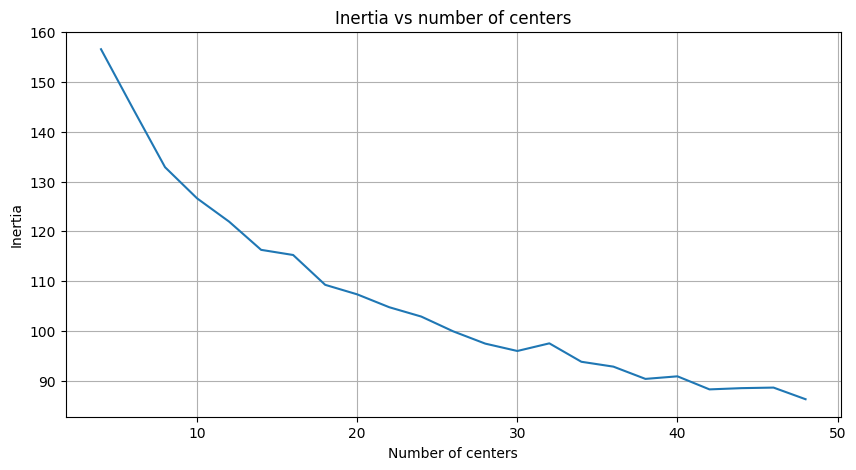

In [24]:
plot_inertia(kmeans_df_namedesc)

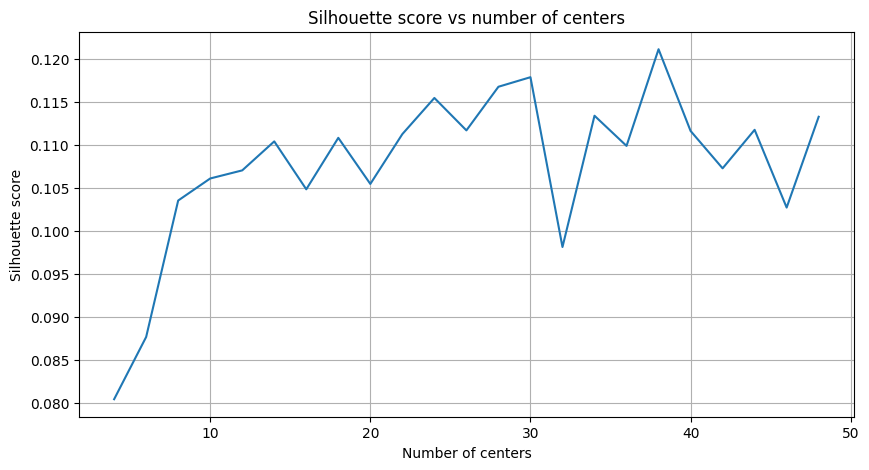

In [25]:
plot_silhouette(kmeans_df_namedesc)

In [26]:
kmeans_df_namedesc.sort_values("silhouette", ascending=False, inplace=True)
kmeans_df_namedesc.head(10)

,n_centers,labels,centers,inertia,silhouette
17,38,"[34, 10, 13, 13, 4, 16, 2, 3, 15, 22, 14, 33, ...","[[-0.025430636, 0.06223624, -0.0038007414, -0....",90.380600,0.121132
13,30,"[0, 21, 14, 5, 13, 14, 3, 24, 19, 5, 16, 24, 1...","[[-0.042454116, 0.087451674, 0.072047815, 0.02...",95.985703,0.117877
12,28,"[25, 26, 27, 22, 5, 26, 15, 9, 0, 3, 12, 19, 0...","[[-0.08626513, -0.07320647, 0.060648434, -0.06...",97.461502,0.116764
10,24,"[5, 18, 6, 7, 8, 3, 13, 20, 6, 15, 21, 4, 6, 1...","[[0.052007966, -0.03247152, 0.0520461, -0.0415...",102.897110,0.115460
15,34,"[9, 8, 0, 19, 22, 8, 2, 20, 11, 12, 18, 20, 0,...","[[-0.045523934, -0.028280541, 0.0656174, -0.04...",93.819839,0.113392
22,48,"[25, 44, 44, 30, 15, 27, 34, 19, 36, 30, 8, 19...","[[-0.013644485, -0.015806796, -0.006760922, -0...",86.300064,0.113270
20,44,"[12, 22, 30, 13, 24, 30, 17, 13, 5, 19, 40, 42...","[[0.09542002, 0.077666186, 0.00024416266, -0.0...",88.524353,0.111753
11,26,"[7, 24, 13, 21, 10, 24, 24, 4, 13, 12, 11, 4, ...","[[0.079437725, -0.06270703, -0.012476058, -0.0...",99.922020,0.111686
18,40,"[1, 9, 9, 24, 18, 9, 21, 29, 31, 36, 7, 29, 31...","[[0.051008187, 0.0021978342, 0.084693514, 0.02...",90.896866,0.111622
9,22,"[0, 1, 9, 5, 17, 2, 7, 20, 9, 4, 13, 20, 9, 10...","[[-0.09095563, 0.114552185, 0.06453448, 0.0421...",104.772606,0.111254


In [27]:
TARGET_CENTER = 10
# fit the kmeans model with the best silhouette score
kmeans_namedesc = MiniBatchKMeans(
    n_clusters=TARGET_CENTER,
    init="k-means++",
    batch_size=64)
kmeans_namedesc.fit(name_desc_embs)
labels_namedesc = kmeans_namedesc.labels_
centers_namedesc = kmeans_namedesc.cluster_centers_
# assign the labels to the original data
clustered_data_namedesc = skills_data.copy()
clustered_data_namedesc["cluster"] = labels_namedesc

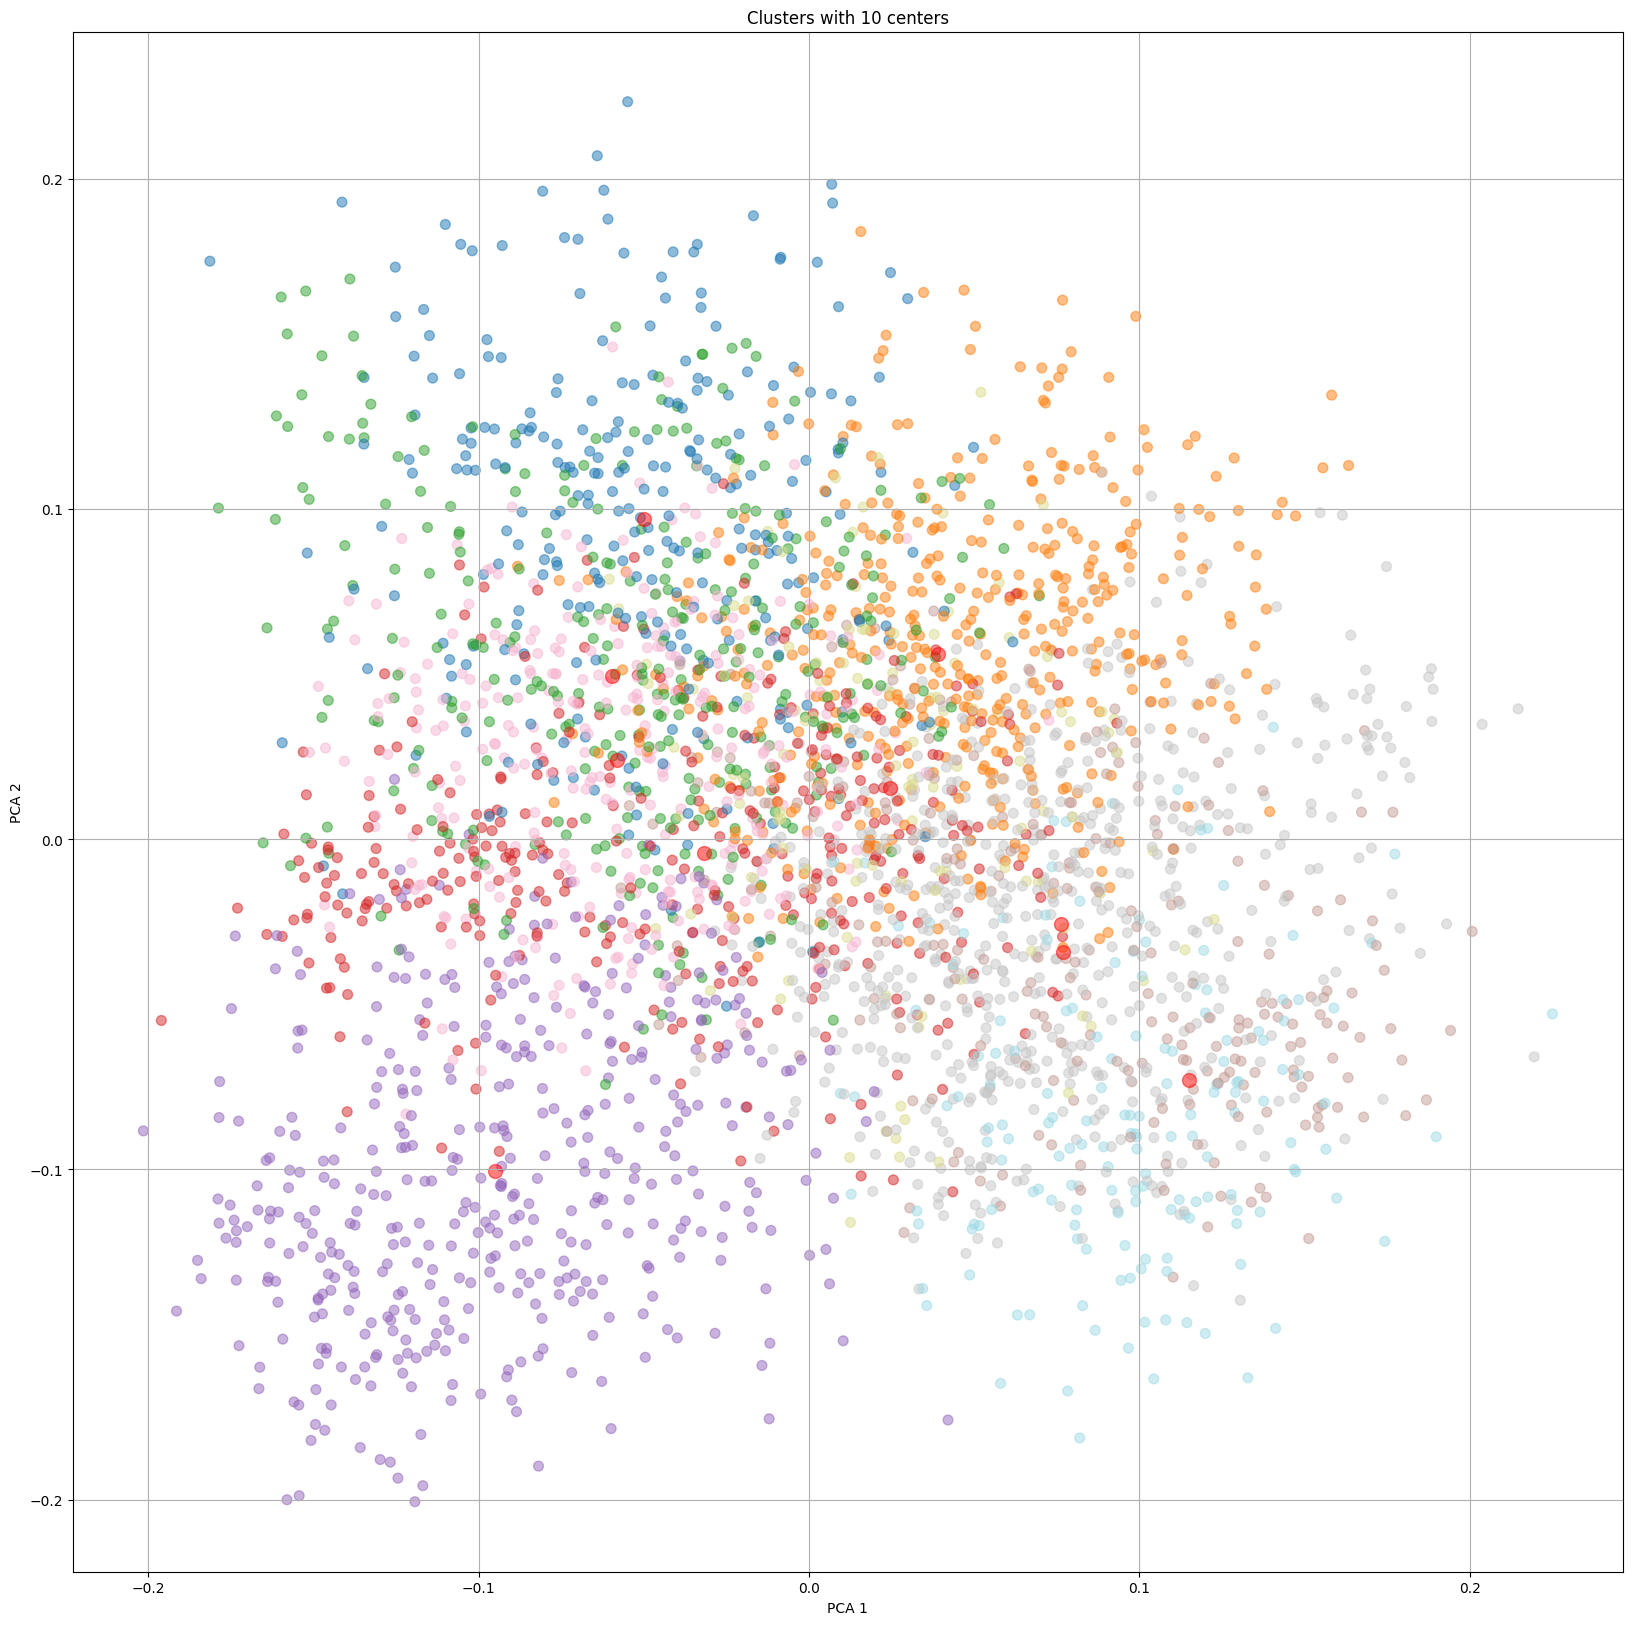

In [28]:
plot_clusters(name_desc_embs, labels=labels_namedesc, centers=centers_namedesc)

In [29]:
# get sample results from each cluster
idx_cls = np.random.choice(clustered_data_namedesc.cluster.unique())

sample_results_namedesc = clustered_data_namedesc[clustered_data_namedesc.cluster == idx_cls].copy()
_max_pop = len(sample_results_namedesc)
sample_results_namedesc = sample_results_namedesc.sample(np.min([15, _max_pop]), replace=False)

print(f"Cluster: {idx_cls}")
# print skill name for each sample result
for i, row in sample_results_namedesc.iterrows():
    print(f"Skill name: {row.skill_name} - {row.skill_motive}")

Cluster: 0
Skill name: Experiencia en Atención al Cliente - Importante para manejar reclamos y solicitudes de clientes de manera eficiente.
Skill name: Experiencia previa - Es un requisito excluyente para el puesto, debido a la naturaleza del trabajo con adultos mayores.
Skill name: Trabajo bajo presión - Habilidad esencial para manejar las exigencias en un entorno industrial.
Skill name: Experiencia en producción - Es necesario para asegurar una correcta elaboración de productos alimentarios.
Skill name: Experiencia en el sector de la construcción - La experiencia previa en posiciones similares es crucial para entender el ambiente de trabajo y los riesgos asociados.
Skill name: Ventas - Se requiere experiencia en ventas para llevar a cabo las responsabilidades asignadas.
Skill name: Experiencia en limpieza - Es necesario para asegurar la calidad del servicio y el mantenimiento del orden en el lugar de trabajo.
Skill name: Experiencia en gastronomía - Se requiere 3 años de experiencia 

/var/folders/2c/s1dc7gqn0jz4dls2kprq822m0000gn/T/ipykernel_59500/2325499040.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color, label=cluster_labels_dict[i], s=50, alpha=0.5)


Text(0, 0.5, 'PCA 2')

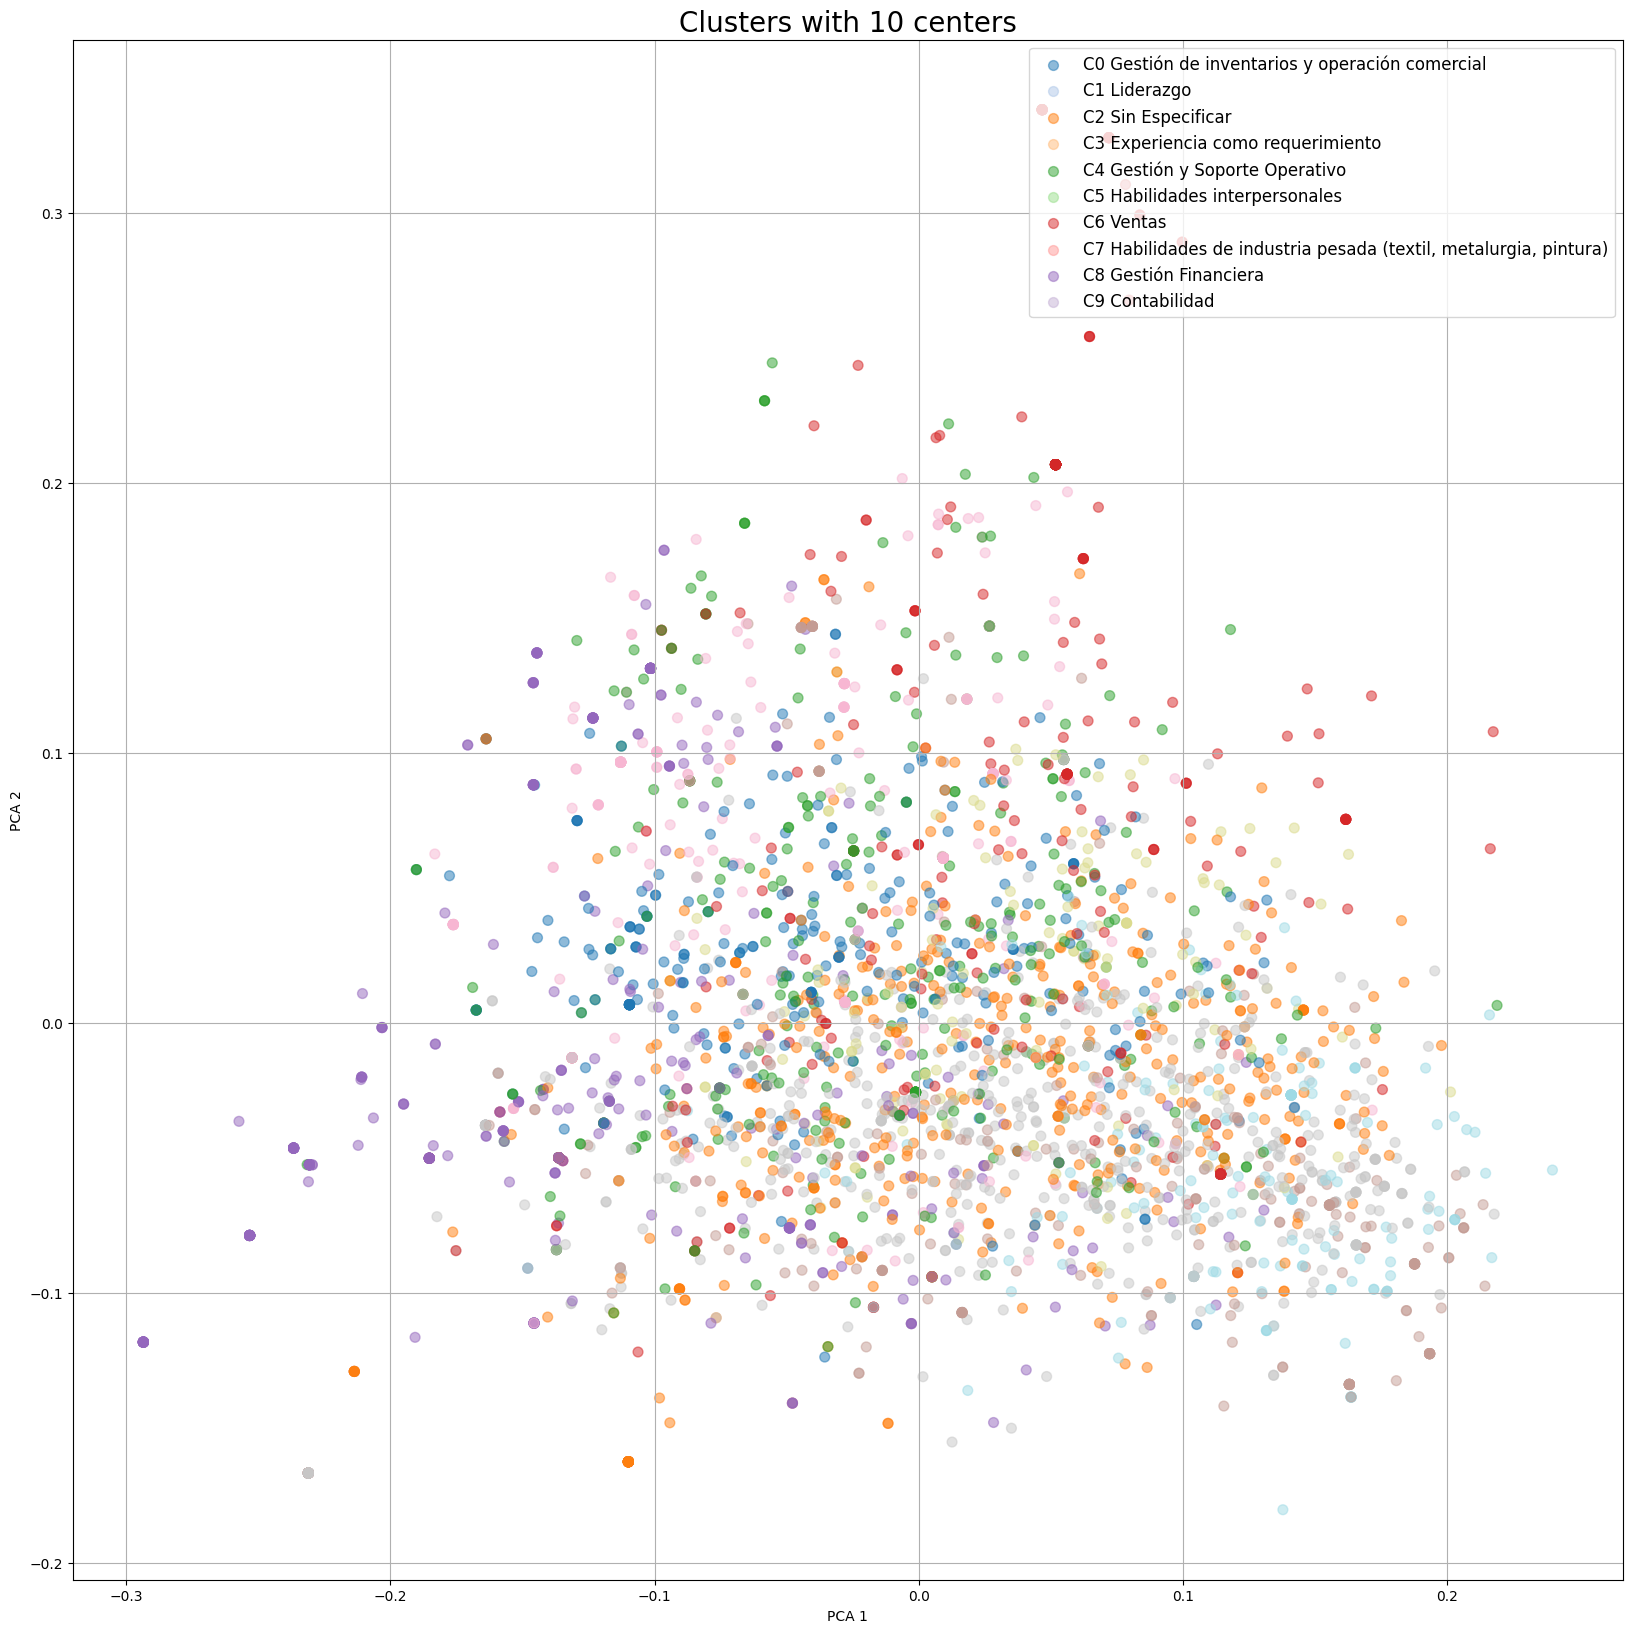

In [32]:
# plot clusters with legend
cluster_labels_dict = {
8:"C8 Gestión Financiera",
4:"C4 Gestión y Soporte Operativo",
9:"C9 Contabilidad",
3:"C3 Experiencia como requerimiento",
7:"C7 Habilidades de industria pesada (textil, metalurgia, pintura)",
6:"C6 Ventas",
5:"C5 Habilidades interpersonales",
0:"C0 Gestión de inventarios y operación comercial",
1:"C1 Liderazgo",
2:"C2 Sin Especificar",
}

plt.figure(figsize=(20,20))
plt.scatter(_plot_x[:, 0], _plot_x[:, 1], c=labels_namedesc, s=50, cmap="tab20", alpha=0.5)

# add legend, one empty space for each cluster
for i in range(len(cluster_labels_dict)):
    # get color for cluster
    color = plt.cm.tab20(i)
    plt.scatter([], [], c=color, label=cluster_labels_dict[i], s=50, alpha=0.5)
plt.legend(loc="upper right", fontsize=12)
plt.grid()

plt.title(f"Clusters with {TARGET_CENTER} centers", fontsize=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

C8 Gestión Financiera

C4 Fuzzy - Gestión y Soporte Operativo

C9 Contabilidad

C3 Experiencia como requerimiento

C7 Fuzzy - Habilidades de industria pesada (textil, metalurgia, pintura)

C6 Ventas

C5 Habilidades interpersonales

C0 Gestión de inventarios y operación comercial

C1 Liderazgo

C2 NaN